<a href="https://colab.research.google.com/github/jaewoo0108/ml/blob/main/week09-unsupervised-kmeans-anomaly/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 9 - Unsupervised Learning

(데이터 : Palmer Penguins)
- K-means
- Anomaly Detection


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
np.random.seed(42)


In [ ]:
## Part 1. K-means

df = sns.load_dataset('penguins')
df = df.dropna() # NaN 값을 포함하는 행 = 측정을 못한 펭귄을 제외한다
df.head()

feat = ['bill_length_mm','flipper_length_mm'] # 군집에 쓸 특성 2개
X = df[feat].values.astype(float)

# 특성별 크기 조정 위한 Z-점수 정규화 : 모든 데이터에서 평균을 빼고 표준 편차로 나눈다
X_std = ( X - X.mean(axis=0)) / X.std(axis=0)
m, n = X_std.shape

print("데이터 개수:", m, " 특성 수 :", n)
print("종 분포:", df['species'].value_counts().to_dict())

데이터 개수: 333  특성 수 : 2
종 분포: {'Adelie': 146, 'Gentoo': 119, 'Chinstrap': 68}


In [ ]:
# K-means : 클러스터 배정과 클러스터 중심점 이동 (두 단계의 반복)

# 1단계 : 각 점을 가장 가까운 클러스터에 배정
def assign_clusters(X, centroids):
  K = centroids.shape[0]
  dists = np.zeros((X.shape[0], K))
  for k in range(K):
    dists[:, k] = np.sum((X - centroids[k])**2, axis=1)
  return np.argmin(dists, axis=1)

# 임의 중심 배정 테스트
test_cent = X_std[[0,100]]
print("배정 결과 앞 10개:",assign_clusters(X_std, test_cent)[:10])

# 2단계 : 클러스터 중심점을 클러스터 점들의 평균으로 이동
def move_centroids(X, c, K):
  new = np.zeros((K, X.shape[1]))
  for k in range(K):
    new[k] = np.mean(X[c == k],axis=0)
  return new

c0 = assign_clusters(X_std, test_cent)
print("이동 후 중심:", move_centroids(X_std, c0, 2).round(3))

배정 결과 앞 10개: [0 0 1 1 0 0 1 0 1 1]
이동 후 중심: [[-0.764 -1.117]
 [ 0.274  0.401]]


In [ ]:
# K-means의 cost function - Distortion function

def distortion(X, c, centroids):
  return np.mean(np.sum((X - centroids[c])**2, axis=1))

print("현재 왜곡 J:",round(distortion(X_std, c0, test_cent),4))

현재 왜곡 J: 2.7596


In [ ]:
# 데이터셋에서 무작위 K개를 초기 중심으로 설정
def init_centroids(X, K):
  idx = np.random.permutation(X.shape[0])[:K]
  return X[idx].copy()

# K-means 실행
def run_kmeans(X, K, iters):
  centroids = init_centroids(X,K)
  history = []
  for i in range(iters):
    c = assign_clusters(X, centroids)  # 1단계
    centroids = move_centroids(X, c, K)  # 2단계
    history.append(distortion(X, c, centroids))
  return c, centroids, history

hist_rounded = []
c, centroids, hist = run_kmeans(X_std, K=3, iters=10)
for h in hist:
  rounded_value = round(h,4)
  hist_rounded.append(rounded_value)
print("매 반복 비용:", hist_rounded)

매 반복 비용: [np.float64(0.6718), np.float64(0.5762), np.float64(0.5478), np.float64(0.535), np.float64(0.5225), np.float64(0.5117), np.float64(0.5017), np.float64(0.4938), np.float64(0.4896), np.float64(0.4801)]


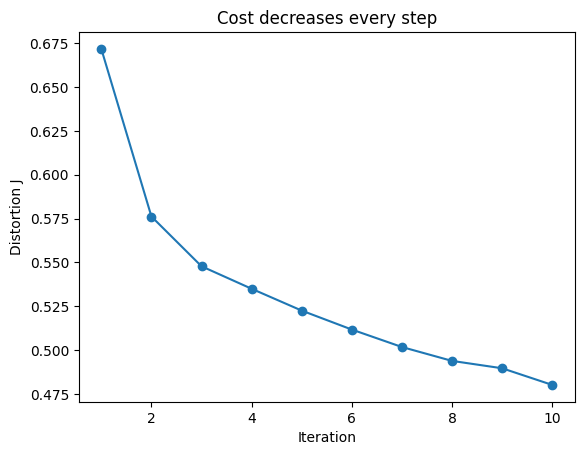

In [ ]:
# 비용 곡선 시각화
plt.plot(range(1, len(hist)+1), hist, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Distortion J")
plt.title("Cost decreases every step")
plt.show()

20회 중 최저 비용 J: 0.465


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


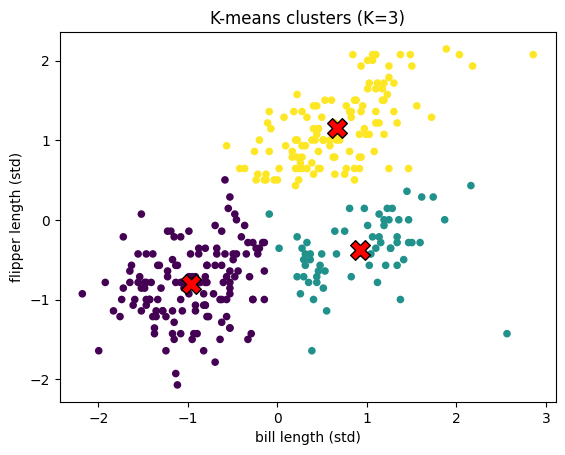

In [ ]:
# Random Initialization을 통해 K-mean을 여러번 실행하고 비교해 지역 최소값 피한다

best_c, best_cent, best_J = None, None, np.inf

for trial in range(20):
  cc, cent, h = run_kmeans(X_std, K=3, iters=10)
  if h[-1] < best_J:
    best_J, best_c, best_cent = h[-1], cc, cent

print("20회 중 최저 비용 J:", round(best_J,4))

# 찾은 3개의 클러스터와 중심점 시각화
plt.scatter(X_std[:, 0], X_std[:, 1], c=best_c, cmap='viridis', s=20)
plt.scatter(best_cent[:, 0], best_cent[:, 1],
            c='red', marker='X', s=200, edgecolor='black')
plt.xlabel("bill length (std)")
plt.ylabel("flipper length (std)")
plt.title("K-means clusters (K=3)")
plt.show()


In [ ]:
# 직접 구현 vs sklearn 결과 대조

km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_std)

print("sklearn J:", round(km.inertia_/m, 4), "My best J:", round(best_J, 4))
print("배정 일치도 (ARI):", round(adjusted_rand_score(best_c, km.labels_), 4))

sklearn J: 0.465 My best J: 0.465
배정 일치도 (ARI): 1.0


In [ ]:
# K-means 활용해 클러스터링한 결과가 실제 펭귄 종과 얼마나 맞는지 채점

species_true = df['species'].values

# 1단계: 각 군집에 어떤 종이 몇 마리 들어있나에 대한 표
ct = pd.crosstab(best_c, df['species'])
print(ct)

# 2단계: 각 군집을 '가장 많은 종'의 이름으로 매핑 (딕셔너리)
cluster_to_species = {}
for cluster in ct.index:
    cluster_to_species[cluster] = ct.loc[cluster].idxmax()
print("\n군집 이름표:", cluster_to_species)

# 3단계: 각 펭귄의 군집번호를 종 이름으로 바꾼다
predicted = [cluster_to_species[c] for c in best_c]

# 4단계: 예측 == 실제 인 개수를 세서 정확도 계산
correct = 0
for i in range(len(best_c)):
    if predicted[i] == species_true[i]:
        correct += 1
print("\n맞은 개수:", correct, "/", len(best_c))
print("정확도:", round(correct / len(best_c), 3))

species  Adelie  Chinstrap  Gentoo
row_0                             
0           141          5       0
1             4         59       1
2             1          4     118

군집 이름표: {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}

맞은 개수: 318 / 333
정확도: 0.955


In [ ]:
## Part 2. Anomaly Detection - Gaussian distribution
# 데이터셋에서 Adelie 종을 정상, Gentoo 종을 이상 데이터로 분류
# train : Adelie 100개, CV : Adelie(46) + Gentoo(10)

# Gentoo와 Adelie 간의 유의미한 차이를 보이는 특성 선택
feat2 = ['flipper_length_mm', 'body_mass_g']
adelie = df[df['species']=='Adelie'][feat2].values.astype(float)
gentoo = df[df['species']=='Gentoo'][feat2].values.astype(float)
np.random.shuffle(adelie)
np.random.shuffle(gentoo)

# 훈련 세트와 검증 세트 구성
X_train = adelie[:100]
X_cv = np.vstack([adelie[100:], gentoo[:30]])
y_cv = np.array([0]*(len(adelie)-100) + [1]*30)

print("train:", len(X_train), " cv:",len(X_cv), " ( 그중 이상:",y_cv.sum(),")")

train: 100  cv: 76  ( 그중 이상: 30 )


In [ ]:
# Gaussian 분포 함수 구현
def estimate_gaussian(X):
  mu = np.mean(X, axis=0)
  var = np.var(X, axis=0)
  return mu, var

def gaussian_prob(X, mu, var):
  coef = 1 / np.sqrt(2*np.pi*var)
  exp = np.exp(-((X-mu)**2)/(2*var))
  return np.prod(coef*exp, axis=1)

mu, var = estimate_gaussian(X_train)
print("mu:",mu.round(1))
print("var:",var.round(1))

mu: [ 189.2 3630.2]
var: [3.930000e+01 2.013912e+05]


In [ ]:
# Cross Validation 셋에서 최적 임계값 epsilon 찾기
from sklearn.metrics import f1_score, precision_score, recall_score

p_cv = gaussian_prob(X_cv, mu, var)
best_eps, best_f1 = 0, 0
for eps in np.linspace(p_cv.min(), p_cv.max(),1000):
  pred = (p_cv < eps).astype(int)
  f1 = f1_score(y_cv, pred, zero_division=0)
  if f1 > best_f1:
    best_f1, best_eps = f1, eps

pred = (p_cv < best_eps).astype(int)
print(f"best epsilon: {best_eps:.2e}")
print("precision:", round(precision_score(y_cv,pred),3),
      " recall:",round(recall_score(y_cv,pred),3),
      " F1:", round(best_f1,3))

best epsilon: 5.05e-07
precision: 0.938  recall: 1.0  F1: 0.968


body_mass 원본 skew : 0.470
body_mass log 변환  : 0.174
flipper_length 원본 skew : 0.359
flipper_length log 변환  : 0.264


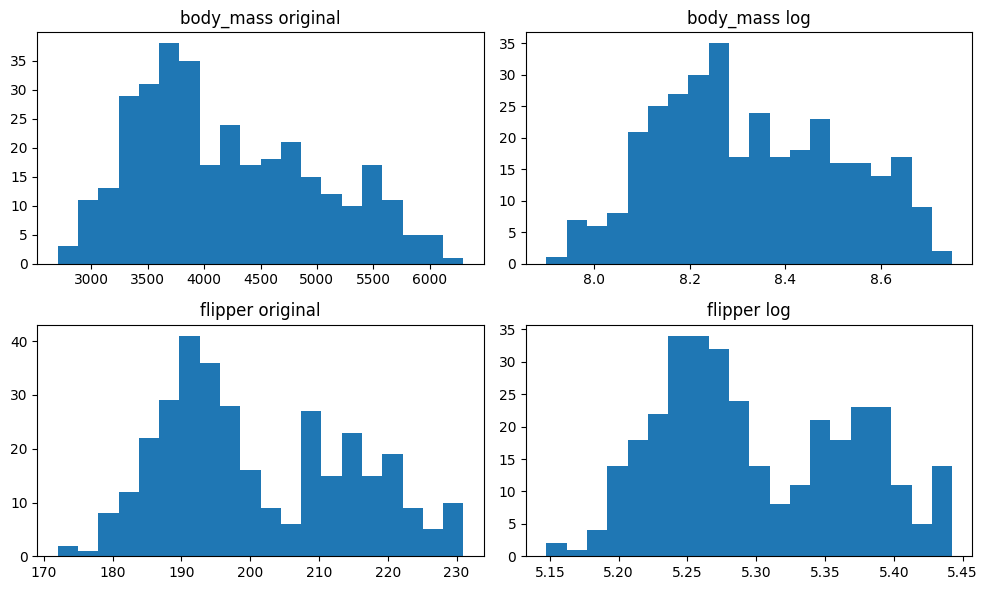

In [ ]:
# feature engineering : 특성의 분포를 정규분포에 가깝게 만든다
# 왜도(치우침) 측정. 0에 가까울수록 좌우대칭(정규분포)

from scipy.stats import skew

bm1 = df['body_mass_g'].values
print(f"body_mass 원본 skew : {skew(bm1):.3f}")        # 오른쪽으로 치우침
print(f"body_mass log 변환  : {skew(np.log(bm1)):.3f}")  # log 후 대칭에 가까워짐

bm2 = df['flipper_length_mm'].values
print(f"flipper_length 원본 skew : {skew(bm2):.3f}")
print(f"flipper_length log 변환  : {skew(np.log(bm2)):.3f}")

fig, ax = plt.subplots(2, 2, figsize=(10, 6))
ax[0,0].hist(bm1, bins=20);          ax[0,0].set_title("body_mass original")
ax[0,1].hist(np.log(bm1), bins=20);  ax[0,1].set_title("body_mass log")
ax[1,0].hist(bm2, bins=20);          ax[1,0].set_title("flipper original")
ax[1,1].hist(np.log(bm2), bins=20);  ax[1,1].set_title("flipper log")
plt.tight_layout(); plt.show()